# Compare pochoir induced current with tred response

- **tred file**: `/home/rrazakami/work/ND-LAr/data_tred/responses/response_44_v2a_full.npz`
- **pochoir file**: `../store/fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy`

## Units note (confirmed empirically)

From `pochoir/__main__.py::induce_pixel`, the current is computed as `I = dQ/dT` where `Q = charge * weighting_potential(path)` and `charge` defaults to `1.0` (= 1 `eplus`). Times come from `pochoir.arrays.fromstr1` evaluating expressions like `0*us,210*us,0.05*us` against `pochoir.units` where `ns = 1` and `us = 1000*ns`. The paths metadata confirms `tstart=0, tstop=210000, nsteps=4200`, so `dT = 50` (ns).

**Pochoir output is in `eplus / ns`.** `Σ(pochoir[i,j]) · 50 ns ≈ 1 eplus` for a path that lands on its pixel.

**tred `response` is in `eplus / us`** (with `time_tick = 0.05 us`). `Σ(tred[i,j]) · 0.05 us ≈ 1 eplus` — verified empirically: `tred[0,0].sum() ≈ 20.0`, and `0.05 × 20 = 1`.

So the unit mismatch is exactly `us/ns = 1000`. To put pochoir on tred's footing:

$$ I_\text{pochoir}\,[\text{e}/\mu s] = I_\text{pochoir}\,[\text{e/ns}] \times 1000 $$


In [1]:
import numpy as np
import matplotlib.pyplot as plt

TRED_PATH = '/home/rrazakami/work/ND-LAr/data_tred/responses/response_44_v2a_full.npz'
POCH_PATH = '../store/fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy'

tred = np.load(TRED_PATH)
print('tred keys:', tred.files)
tred_resp = tred['response']
tred_tick = float(tred['time_tick'])  # microseconds
tred_drift = float(tred['drift_length'])
tred_bin = float(tred['bin_size'])
print(f'tred response shape : {tred_resp.shape}  dtype={tred_resp.dtype}')
print(f'tred time_tick      : {tred_tick} us')
print(f'tred drift_length   : {tred_drift}')
print(f'tred bin_size       : {tred_bin}')

poch = np.load(POCH_PATH)
print(f'\npochoir shape       : {poch.shape}  dtype={poch.dtype}')
print(f'pochoir min/max     : {poch.min():.4e}  {poch.max():.4e}')

tred keys: ['response', 'drift_length', 'time_tick', 'bin_size']
tred response shape : (45, 45, 3900)  dtype=float64
tred time_tick      : 0.05 us
tred drift_length   : 30.431
tred bin_size       : 0.04434

pochoir shape       : (2025, 4199)  dtype=float64
pochoir min/max     : -1.0370e-03  2.3549e-03


In [2]:
# Pochoir time step from the gen script (test-full-3d-pixel.sh): paths use '0*us,210*us,0.05*us'
DT_NS = 50.0  # 0.05 us
DT_US = 0.05

# Pochoir I = dQ/dT in eplus/ns. Multiply by dT_ns to get dQ per tick (eplus per tick).
poch_dq = poch * DT_NS
print('pochoir dQ/tick  min/max:', poch_dq.min(), poch_dq.max())
print('tred response    min/max:', tred_resp.min(), tred_resp.max())

pochoir dQ/tick  min/max: -0.05185005879649408 0.11774620008416005
tred response    min/max: -2.006248780134882 4.890734857073539


## Reshape pochoir to a 2D grid of paths

`fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npy` has shape `(2025, 4199)`. `2025 = 45 x 45`, matching the tred 45x45 transverse grid. Reshape so axes line up.

In [3]:
Ny, Nx = 45, 45
assert poch.shape[0] == Ny * Nx, f'unexpected pochoir paths count: {poch.shape[0]}'
poch_grid = poch_dq.reshape(Ny, Nx, -1)  # (y, x, time)
print('poch_grid shape:', poch_grid.shape)
print('tred shape     :', tred_resp.shape)

poch_grid shape: (45, 45, 4199)
tred shape     : (45, 45, 3900)


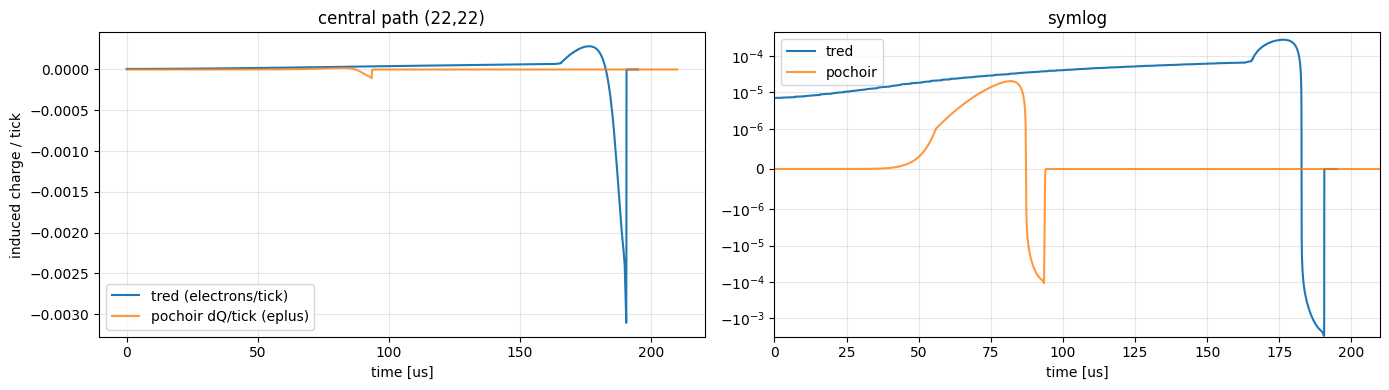

In [4]:
# Compare the central-pixel waveform.
cy, cx = Ny // 2, Nx // 2
wf_poch = poch_grid[cy, cx]
wf_tred = tred_resp[cy, cx]

t_poch = np.arange(wf_poch.size) * DT_US
t_tred = np.arange(wf_tred.size) * tred_tick

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(t_tred, wf_tred, label='tred (electrons/tick)')
ax[0].plot(t_poch, wf_poch, label='pochoir dQ/tick (eplus)', alpha=0.8)
ax[0].set_xlabel('time [us]'); ax[0].set_ylabel('induced charge / tick')
ax[0].set_title(f'central path ({cy},{cx})')
ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(t_tred, wf_tred, label='tred')
ax[1].plot(t_poch, wf_poch, label='pochoir', alpha=0.8)
ax[1].set_xlim(0, max(t_tred[-1], t_poch[-1]))
ax[1].set_yscale('symlog', linthresh=1e-6)
ax[1].set_xlabel('time [us]'); ax[1].set_title('symlog')
ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

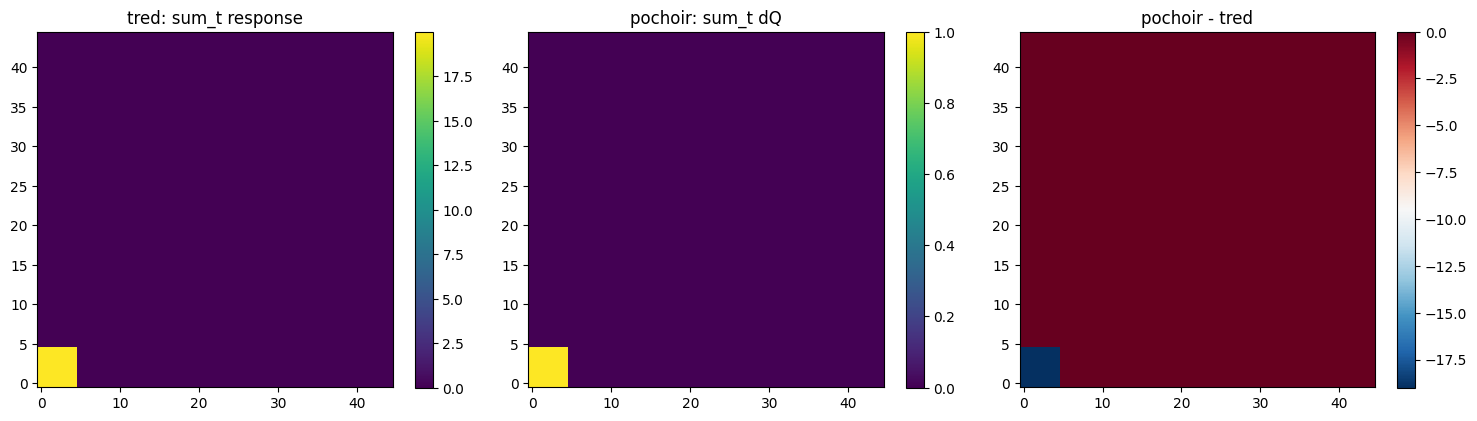

In [5]:
# Integrated induced charge map (sum over time) - should approach +/-1 e for paths that land on/off the pixel.
poch_sum = poch_grid.sum(axis=-1)
tred_sum = tred_resp.sum(axis=-1)

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].imshow(tred_sum, origin='lower'); ax[0].set_title('tred: sum_t response'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(poch_sum, origin='lower'); ax[1].set_title('pochoir: sum_t dQ'); plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(poch_sum - tred_sum, origin='lower', cmap='RdBu_r'); ax[2].set_title('pochoir - tred'); plt.colorbar(im2, ax=ax[2])
plt.tight_layout(); plt.show()

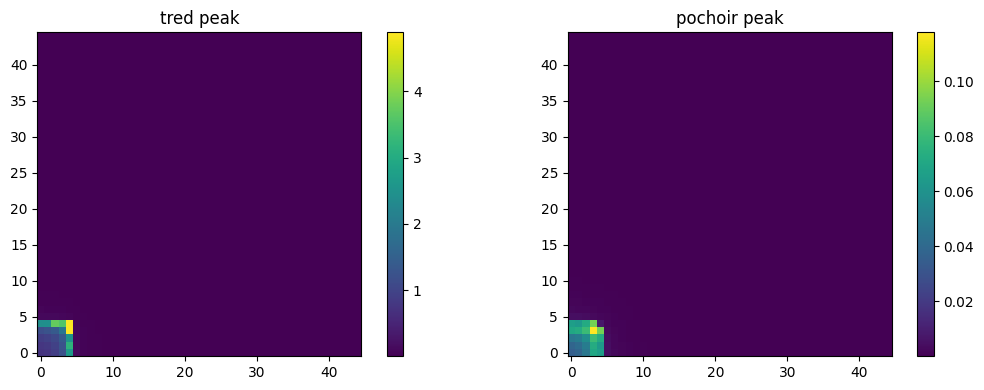

In [6]:
# Peak-induced amplitude map.
poch_peak = poch_grid.max(axis=-1)
tred_peak = tred_resp.max(axis=-1)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
im0 = ax[0].imshow(tred_peak, origin='lower'); ax[0].set_title('tred peak'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(poch_peak, origin='lower'); ax[1].set_title('pochoir peak'); plt.colorbar(im1, ax=ax[1])
plt.tight_layout(); plt.show()

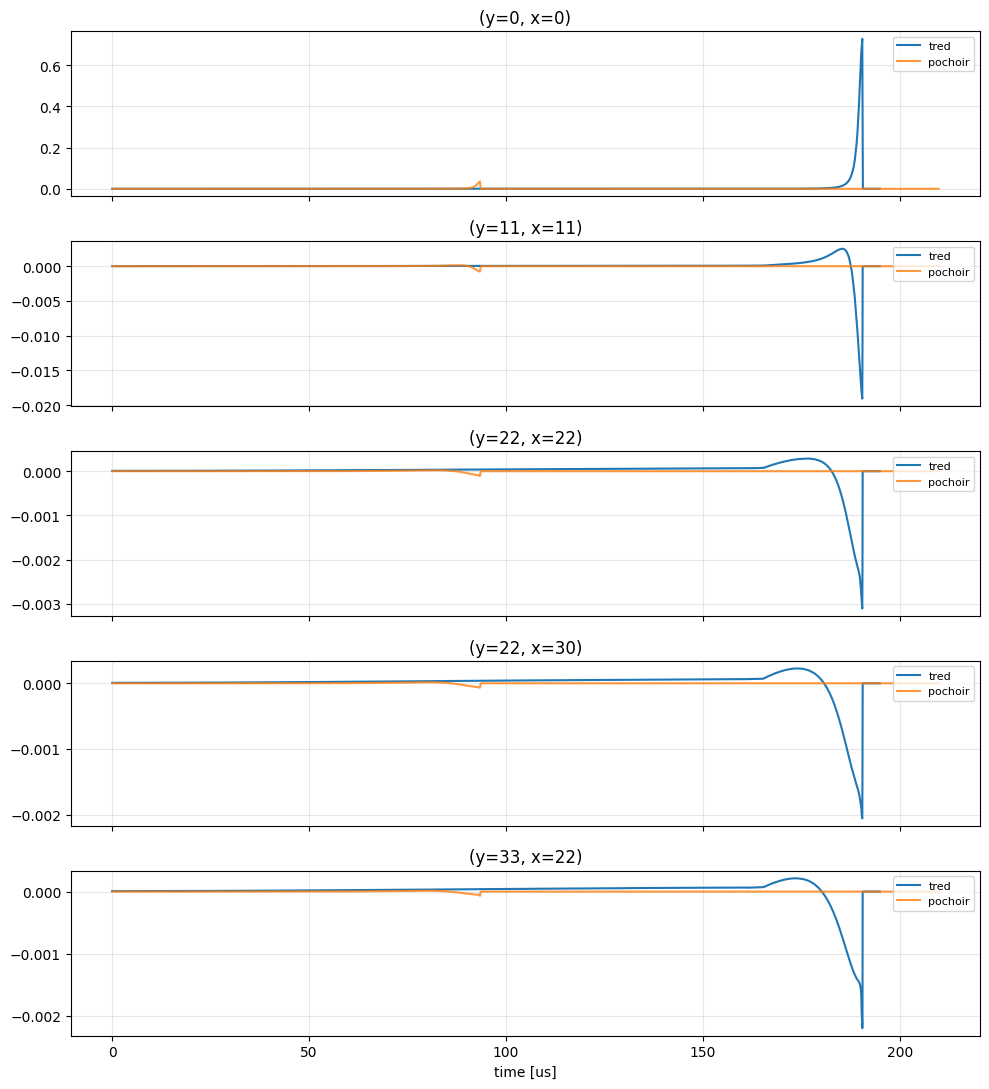

In [7]:
# Side-by-side waveforms for a few off-center positions to check the comparison holds away from the central pixel.
offsets = [(0,0),(11,11),(22,22),(22,30),(33,22)]
fig, axes = plt.subplots(len(offsets), 1, figsize=(10, 2.2*len(offsets)), sharex=True)
for ax, (iy, ix) in zip(axes, offsets):
    ax.plot(t_tred, tred_resp[iy, ix], label='tred')
    ax.plot(t_poch, poch_grid[iy, ix], label='pochoir', alpha=0.8)
    ax.set_title(f'(y={iy}, x={ix})'); ax.grid(True, alpha=0.3); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('time [us]')
plt.tight_layout(); plt.show()

## Aligning the two grids

### Convention (from `LArPix_Field_Simulation/larpix_v2b_2mmpad/responsev2b_2mmpad_dict.py`)

```python
step = np.arange(bin/2, bin/2 + bin*45, bin)
for i in range(45):
    for j in range(45):
        drifte.DriftElectron(step[i], step[j], drift_length, 0)
```

Array index `(i, j)` ↔ physical position `((i+0.5)·bin, (j+0.5)·bin)` measured **from the pixel center at the origin**. The 45×45 grid samples one quadrant by symmetry: `(0, 0)` sits half a bin out from the pixel center; the on-pixel region runs over indices `0..(N_half−1)` with `N_half = pixel_pitch / (2·bin)`.

For this comparison file (`bin = 0.04434 cm`, pitch ≈ 4.4 mm): `N_half = 5` → on-pixel indices `0..4`, pixel-edge corner at `(4, 4)`. The 25-point plateau centroid `(2.0, 2.0)` we observe in both files confirms this.

### What was wrong before

I had used `argmax(integrated charge)` (saturates over the plateau → arbitrary index) and then `argmax(peak amplitude)` (which by Ramo's theorem is largest at the **pixel edge**, not center) — landing at `(3,3)` for pochoir and `(4,4)` for tred, two different physical positions. So `dy=dx=1` ended up plotting **on-pixel-edge for pochoir vs off-pixel for tred** — that's the source of the apparent huge difference.

### Correct alignment

Both files use the same `(i,j) → (x,y)` mapping, so just compare at **identical `(i,j)` with no shift**. Pixel center sits at the `(0,0)` symmetry corner (extrapolated half a bin); pixel-edge corner at `(4,4)`; off-pixel for `i>4` or `j>4`.

In [8]:
# Locate each grid's pixel CENTER.
#
# WRONG metric: argmax of integrated charge. Integrated charge saturates to ~1 eplus
# across the *entire* pixel area (a 5x5 plateau here in both grids), so its argmax
# returns an arbitrary point on that plateau, not the geometric center.
#1
# RIGHT metric: argmax of the peak induced-current amplitude. The peak is largest right
# under the pixel center (sharpest spike as the charge arrives at the pad) and falls off
# near pixel edges. Cross-check with the centroid of the saturated (>0.99) region.

# poch_grid is in eplus/tick (poch * DT_NS), so .sum() over time -> eplus.
# tred_resp is in eplus/us, so .sum() * tred_tick -> eplus.
poch_int = poch_grid.sum(axis=-1)
tred_int = tred_resp.sum(axis=-1) * tred_tick

poch_peak_amp = poch_grid.max(axis=-1)
tred_peak_amp = tred_resp.max(axis=-1)

py, px = np.unravel_index(np.argmax(poch_peak_amp), poch_peak_amp.shape)
ty, tx = np.unravel_index(np.argmax(tred_peak_amp), tred_peak_amp.shape)

def centroid(mask):
    ys, xs = np.where(mask)
    if ys.size == 0:
        return float('nan'), float('nan')
    return ys.mean(), xs.mean()

pcy, pcx = centroid(poch_int > 0.99)
tcy, tcx = centroid(tred_int > 0.99)

print(f'pochoir pixel-center (peak-amp argmax) : ({py},{px})  peak={poch_peak_amp[py,px]:.4e}')
print(f'pochoir pixel-center (plateau centroid): ({pcy:.1f},{pcx:.1f})  ({(poch_int>0.99).sum()} on-pixel paths)')
print(f'tred    pixel-center (peak-amp argmax) : ({ty},{tx})  peak={tred_peak_amp[ty,tx]:.4e}')
print(f'tred    pixel-center (plateau centroid): ({tcy:.1f},{tcx:.1f})  ({(tred_int>0.99).sum()} on-pixel paths)')
print(f'\npochoir on-pixel integrated charge: {poch_int[py,px]:.4f} eplus')
print(f'tred    on-pixel integrated charge: {tred_int[ty,tx]:.4f} eplus')

t_drift_poch = np.argmax(np.abs(poch_grid[py, px])) * DT_US
t_drift_tred = np.argmax(np.abs(tred_resp[ty, tx])) * tred_tick
print(f'\npochoir on-pixel peak time: {t_drift_poch:.2f} us  (drift ~14.6 cm)')
print(f'tred    on-pixel peak time: {t_drift_tred:.2f} us  (drift ~30.4 cm)')

pochoir pixel-center (peak-amp argmax) : (3,3)  peak=1.1775e-01
pochoir pixel-center (plateau centroid): (2.0,2.0)  (25 on-pixel paths)
tred    pixel-center (peak-amp argmax) : (4,4)  peak=4.8907e+00
tred    pixel-center (plateau centroid): (2.0,2.0)  (25 on-pixel paths)

pochoir on-pixel integrated charge: 1.0000 eplus
tred    on-pixel integrated charge: 1.0000 eplus

pochoir on-pixel peak time: 93.45 us  (drift ~14.6 cm)
tred    on-pixel peak time: 190.90 us  (drift ~30.4 cm)


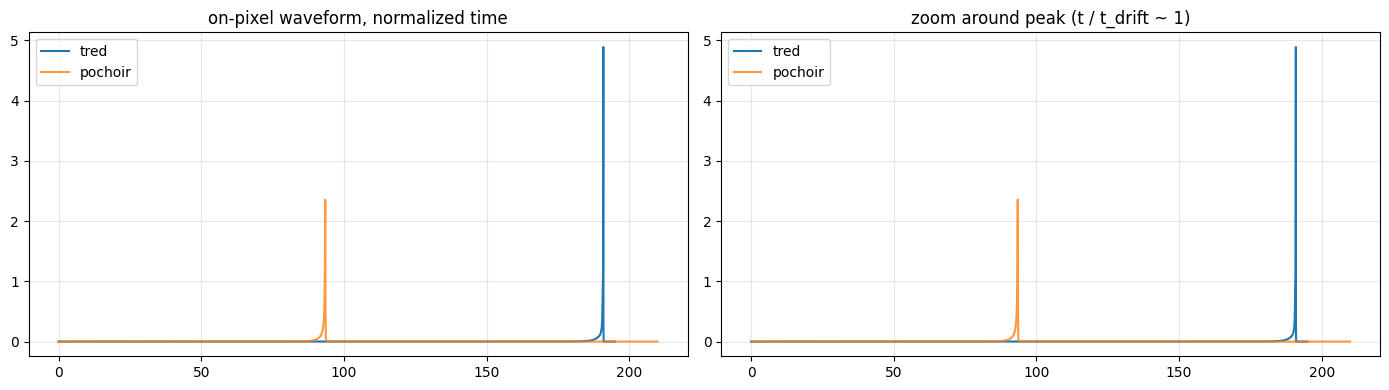

In [9]:
# On-pixel waveforms vs. NORMALIZED drift time (t / t_drift).
# Pochoir is in eplus/ns; tred is in eplus/us. Multiply pochoir by 1000 to match.
NS_PER_US = 1000.0

wf_p = poch_grid[py, px] * NS_PER_US / DT_NS  # back to eplus/us; equivalently poch[idx]*1000 in original eplus/ns
# (poch_grid was poch*DT_NS so it's eplus/tick; convert to eplus/us by dividing by tick width in us=DT_US)
wf_p = poch_grid[py, px]  / DT_US              # eplus/us
wf_t = tred_resp[ty, tx]                       # eplus/us

t_p = np.arange(wf_p.size) * DT_US# / t_drift_poch
t_t = np.arange(wf_t.size) * tred_tick #/ t_drift_tred

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].plot(t_t, wf_t, label='tred')
ax[0].plot(t_p, wf_p, label='pochoir', alpha=0.8)
# ax[0].set_xlim(0, 1.2); ax[0].set_xlabel('t / t_drift'); ax[0].set_ylabel('induced current [eplus / us]')
ax[0].set_title('on-pixel waveform, normalized time'); ax[0].legend(); ax[0].grid(True, alpha=0.3)

ax[1].plot(t_t, wf_t, label='tred')
ax[1].plot(t_p, wf_p, label='pochoir', alpha=0.8)
# ax[1].set_xlim(0.85, 1.05); ax[1].set_xlabel('t / t_drift')
ax[1].set_title('zoom around peak (t / t_drift ~ 1)'); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [10]:
from scipy.integrate import trapezoid, simpson              

print('RESULTS FROM POCHOIR')                                                        
area = trapezoid(wf_p, t_p)   # trapezoidal rule
print(f'Area using trapezoid rule: {area}')
area = simpson(wf_p, x=t_p)   # Simpson's rule (more        
print(f'Area using simpson\'s rule : {area}')

print('RESULTS FROM Jiangmei\'s CALCULATION')
area = trapezoid(wf_t, t_t)   # trapezoidal rule
print(f'Area using trapezoid rule: {area}')
area = simpson(wf_t, x=t_t)   # Simpson's rule (more        
print(f'Area using simpson\'s rule : {area}')

RESULTS FROM POCHOIR
Area using trapezoid rule: 0.9999999999993253
Area using simpson's rule : 1.004892595642234
RESULTS FROM Jiangmei's CALCULATION
Area using trapezoid rule: 0.9999740819353405
Area using simpson's rule : 0.9569872221527237


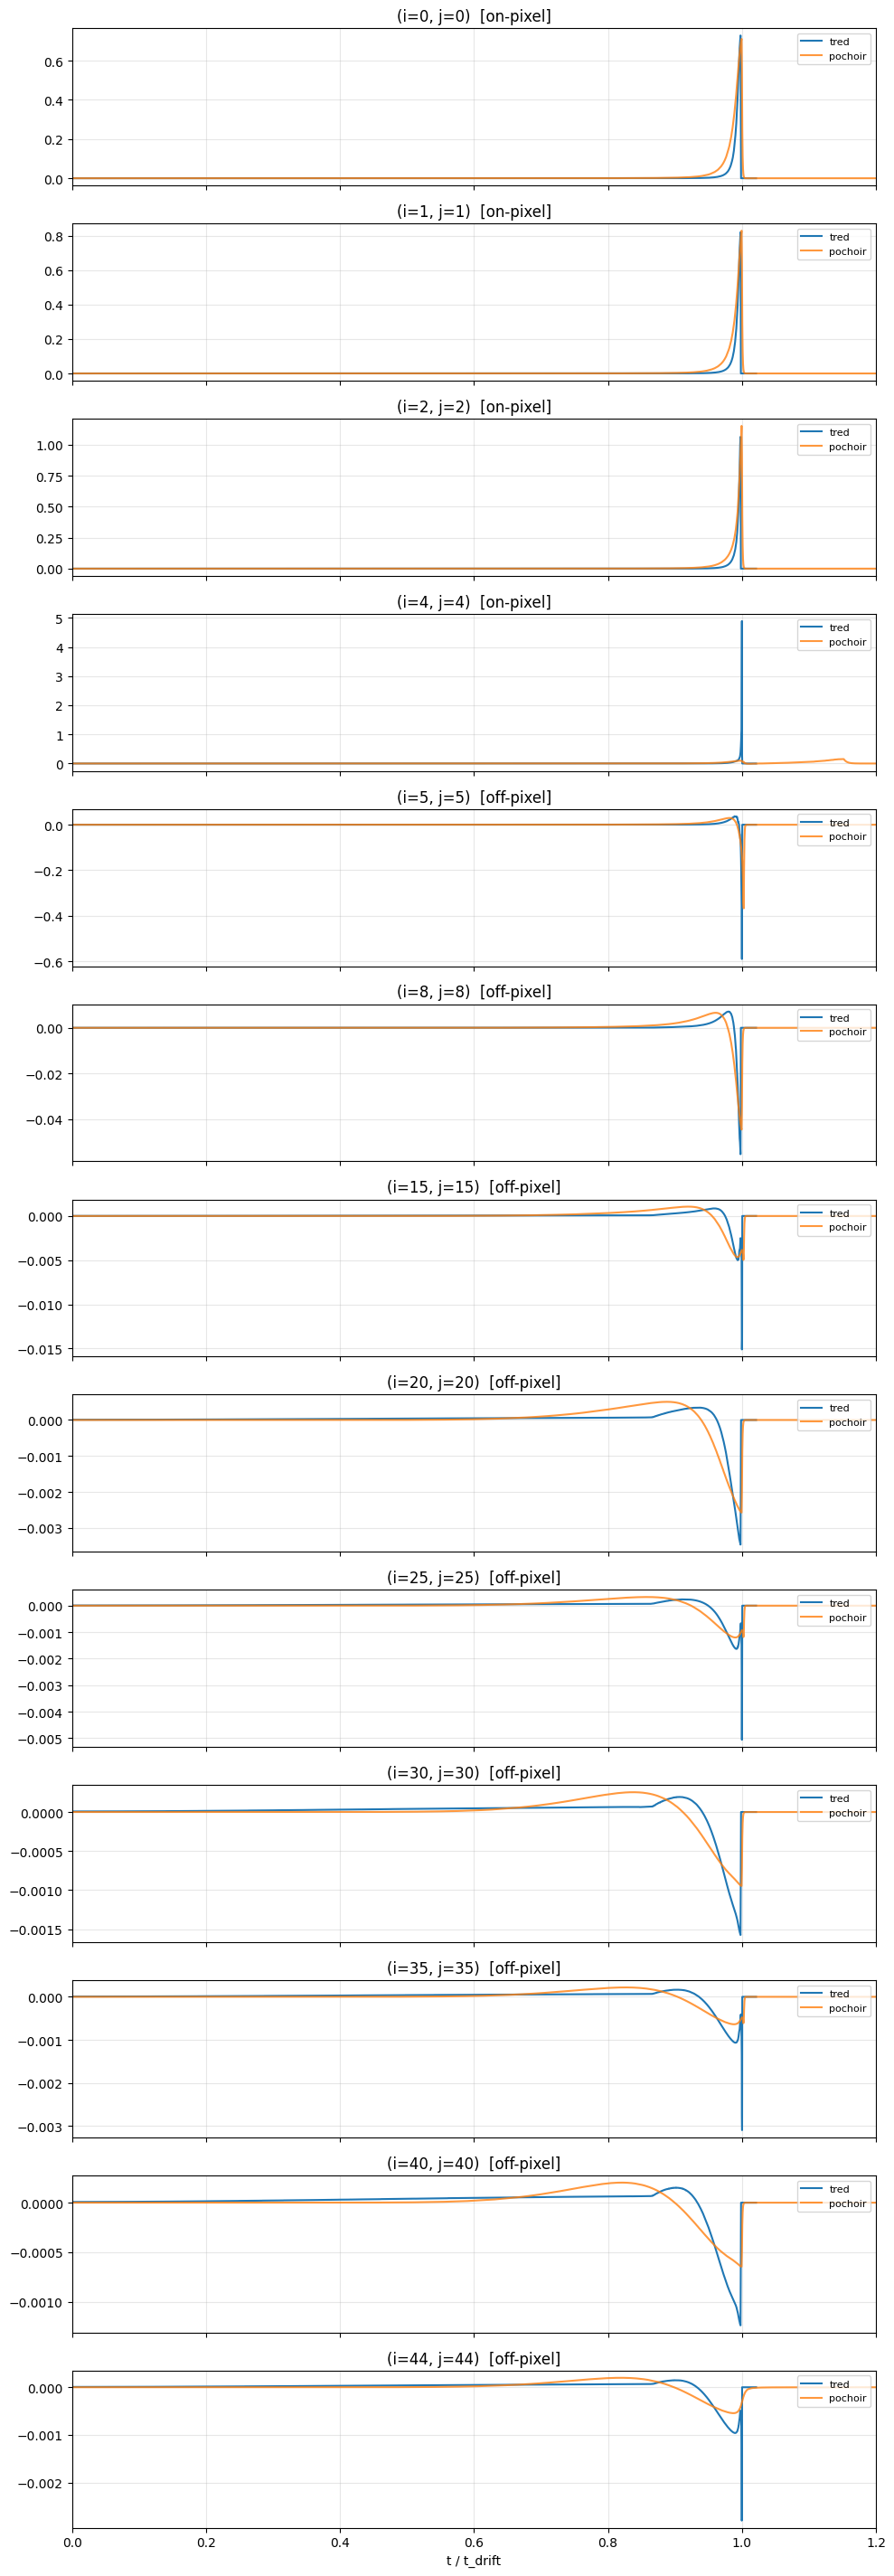

In [11]:
# Both files use the same (i,j) -> (x,y) mapping (plateau centroid (2,2) in both, on-pixel
# region indices 0..4). The "pixel center" in this convention is (0,0) - these files store
# one symmetry quadrant. So compare directly at identical (i,j); NO shift between them.
#
# Note: the peak induced current is biggest at the pixel EDGE (Ramo dQ/dt ~ v.grad(W);
# largest where W changes fastest). So argmax(peak_amp) gives an edge index (3,3)/(4,4),
# not the geometric center.

PIX_HALF = 4  # on-pixel quadrant runs i,j in [0..PIX_HALF]
positions = [
    (0, 0),  # pixel center (symmetry corner)
    (1, 1),
    (2, 2),
    (4, 4),  # pixel edge corner
    (5, 5),  # just off-pixel
    (8, 8),
    (15, 15),
    (20, 20),
    (25, 25),
    (30, 30),
    (35, 35),
    (40, 40),
    (44, 44)
]

fig, axes = plt.subplots(len(positions), 1, figsize=(10, 2.2*len(positions)), sharex=True)
for ax, (iy, ix) in zip(axes, positions):
    wp = poch_grid[iy, ix] / DT_US        # eplus/us
    wt = tred_resp[iy, ix]                 # eplus/us
    tp = np.arange(wp.size) * DT_US / t_drift_poch
    tt = np.arange(wt.size) * tred_tick / t_drift_tred
    region = 'on-pixel' if (iy <= PIX_HALF and ix <= PIX_HALF) else 'off-pixel'
    ax.plot(tt, wt, label='tred')
    ax.plot(tp, wp, label='pochoir', alpha=0.8)
    ax.set_xlim(0, 1.2)
    ax.set_title(f'(i={iy}, j={ix})  [{region}]')#   pixel-center=(0,0), pixel-edge corner=(4,4)')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('t / t_drift')
plt.tight_layout(); plt.show()

## Compare POCH (.npy raw induce-pixel output) vs `for_pixel/fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npz`

The `.npz` file is a packaged pochoir response in tred-style format (keys: `response, drift_length, bin_size, time_tick, npath`). It's smaller (25×25×2000) and already in `eplus/us`. We expect it to match the raw `.npy` once we (a) convert the `.npy` from `eplus/ns` to `eplus/us`, and (b) crop to the same 25×25 quadrant.

In [53]:
POCH_NPZ_PATH = 'fr_4p4pitch_3.8pix_nogrid_10pathsperpixel.npz'
pnpz = np.load(POCH_NPZ_PATH)
print('npz keys :', pnpz.files)
poch_npz_resp = pnpz['response']
poch_npz_tick = float(pnpz['time_tick'])
poch_npz_drift = float(pnpz['drift_length'])
poch_npz_bin = float(pnpz['bin_size'])
poch_npz_npath = int(pnpz['npath'])
print(f'response shape   : {poch_npz_resp.shape}  dtype={poch_npz_resp.dtype}')
print(f'time_tick        : {poch_npz_tick} us')
print(f'drift_length     : {poch_npz_drift} cm')
print(f'bin_size         : {poch_npz_bin} cm')
print(f'npath            : {poch_npz_npath}')
print(f'response min/max : {poch_npz_resp.min():.4e}  {poch_npz_resp.max():.4e}')
print()
print(f'raw .npy (poch_grid) shape: {poch_grid.shape}  units: eplus/tick (= poch[eplus/ns] * dT_ns)')
print(f'raw .npy drift   : 14.6 cm (from startpoints)')
print(f'.npz drift_length: {poch_npz_drift} cm  -> they should be on the SAME drift geometry')

npz keys : ['response', 'drift_length', 'bin_size', 'time_tick', 'npath']
response shape   : (25, 25, 2000)  dtype=float64
time_tick        : 0.05 us
drift_length     : 13.79 cm
bin_size         : 0.044340000000000004 cm
npath            : 10
response min/max : -1.4510e+00  2.7982e+00

raw .npy (poch_grid) shape: (45, 45, 4199)  units: eplus/tick (= poch[eplus/ns] * dT_ns)
raw .npy drift   : 14.6 cm (from startpoints)
.npz drift_length: 13.79 cm  -> they should be on the SAME drift geometry


poch_npy [eplus/us] shape: (45, 45, 4199)  cropped: (25, 25, 4199)
poch_npz [eplus/us] shape: (25, 25, 2000)


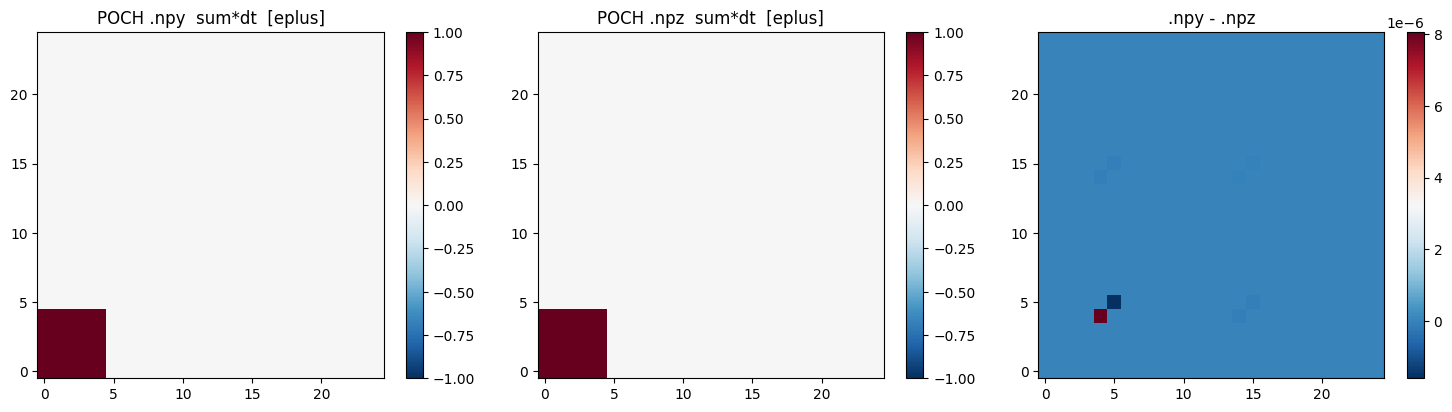


on-pixel integrated charge:
  .npy [0,0]: 1.0000 eplus    .npz [0,0]: 1.0000 eplus
  .npy [4,4]: 1.0000 eplus    .npz [4,4]: 1.0000 eplus
  .npy [10,10]: -3.6611e-18      .npz [10,10]: -9.3475e-14


In [54]:
# Put both POCH arrays in the same units (eplus/us) and crop the .npy to a 25x25 quadrant.
# - .npy  poch_grid is in eplus/tick (= poch * DT_NS); convert to eplus/us by /DT_US.
# - .npz  poch_npz_resp is already in eplus/us.
poch_npy_us = poch_grid / DT_US                     # (45, 45, 4199)
poch_npy_us_25 = poch_npy_us[:25, :25, :]           # crop to the .npz quadrant size

print('poch_npy [eplus/us] shape:', poch_npy_us.shape, ' cropped:', poch_npy_us_25.shape)
print('poch_npz [eplus/us] shape:', poch_npz_resp.shape)

# Integrated charge maps (should both saturate to ~1 e on-pixel).
npy_int_25 = poch_npy_us_25.sum(axis=-1) * DT_US
npz_int    = poch_npz_resp.sum(axis=-1) * poch_npz_tick

vmax = max(np.abs(npy_int_25).max(), np.abs(npz_int).max())
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
im0 = ax[0].imshow(npy_int_25, origin='lower', vmin=-vmax, vmax=vmax, cmap='RdBu_r')
ax[0].set_title('POCH .npy  sum*dt  [eplus]'); plt.colorbar(im0, ax=ax[0])
im1 = ax[1].imshow(npz_int, origin='lower', vmin=-vmax, vmax=vmax, cmap='RdBu_r')
ax[1].set_title('POCH .npz  sum*dt  [eplus]'); plt.colorbar(im1, ax=ax[1])
im2 = ax[2].imshow(npy_int_25 - npz_int, origin='lower', cmap='RdBu_r')
ax[2].set_title('.npy - .npz'); plt.colorbar(im2, ax=ax[2])
plt.tight_layout(); plt.show()

print(f'\non-pixel integrated charge:')
print(f'  .npy [0,0]: {npy_int_25[0,0]:.4f} eplus    .npz [0,0]: {npz_int[0,0]:.4f} eplus')
print(f'  .npy [4,4]: {npy_int_25[4,4]:.4f} eplus    .npz [4,4]: {npz_int[4,4]:.4f} eplus')
print(f'  .npy [10,10]: {npy_int_25[10,10]:.4e}      .npz [10,10]: {npz_int[10,10]:.4e}')

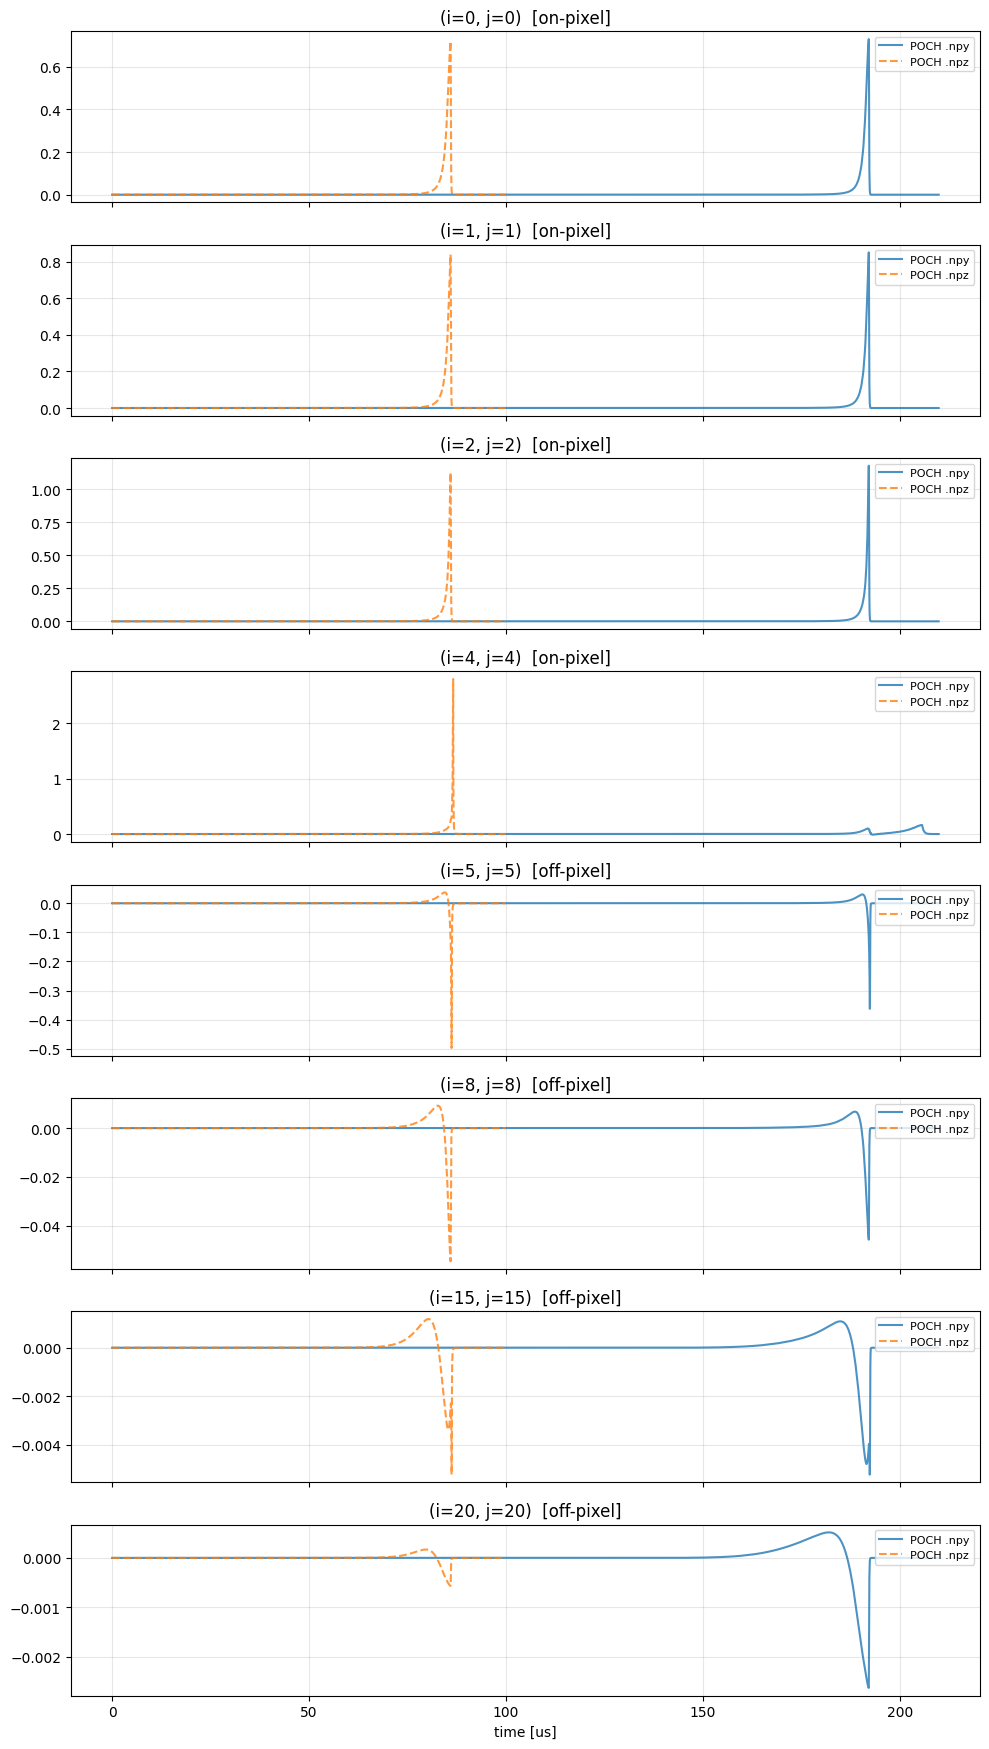

In [55]:
# Waveforms at a few (i,j) -- raw time axis (us), not normalized.
# Both files should describe the same drift geometry (drift ~14 cm), so axes line up directly.
positions = [(0,0), (1,1), (2,2), (4,4), (5,5), (8,8), (15,15), (20,20)]

t_npy = np.arange(poch_npy_us.shape[-1]) * DT_US
t_npz = np.arange(poch_npz_resp.shape[-1]) * poch_npz_tick

fig, axes = plt.subplots(len(positions), 1, figsize=(10, 2.2*len(positions)), sharex=True)
for ax, (iy, ix) in zip(axes, positions):
    if iy >= poch_npz_resp.shape[0] or ix >= poch_npz_resp.shape[1]:
        ax.set_title(f'(i={iy}, j={ix}) out of .npz range'); continue
    wp_npy = poch_npy_us[iy, ix]
    wp_npz = poch_npz_resp[iy, ix]
    region = 'on-pixel' if (iy <= 4 and ix <= 4) else 'off-pixel'
    ax.plot(t_npy, wp_npy, label='POCH .npy', alpha=0.8)
    ax.plot(t_npz, wp_npz, label='POCH .npz', alpha=0.8, ls='--')
    ax.set_title(f'(i={iy}, j={ix})  [{region}]')
    ax.grid(True, alpha=0.3); ax.legend(loc='upper right', fontsize=8)
axes[-1].set_xlabel('time [us]')
plt.tight_layout(); plt.show()